<style>
.jp-Notebook, .notebook-container { max-width: 1120px; margin: auto; }
h1, h2, h3 { color: #1f2937; }
blockquote { border-left: 5px solid #64748b; padding: 0.7rem 1rem; background: #f8fafc; }
table { font-size: 0.92rem; }
.callout { border: 1px solid #cbd5e1; border-radius: 8px; padding: 1rem 1.2rem; background: #f8fafc; margin: 1rem 0; }
.key { border-left: 5px solid #166534; background: #f0fdf4; padding: 1rem 1.2rem; }
.warn { border-left: 5px solid #92400e; background: #fffbeb; padding: 1rem 1.2rem; }
</style>

# Anexo estadístico complementario
## Reanálisis probabilístico del momento de aplicación del nitrógeno en *Festuca arundinacea* Schreb. cv. Rizar

**Documento complementario a la tesis de grado**  
**Datos:** ciclo productivo 2025, sectores de secano y riego suplementario  
**Versión:** modelo de rendimiento corregido y análisis depurado  

---

Este anexo no reemplaza el análisis convencional de la tesis. Su objetivo es traducir las conclusiones principales a afirmaciones probabilísticas, evaluar su robustez frente a decisiones de modelado y distinguir con mayor claridad entre ausencia de evidencia, equivalencia práctica y evidencia de mecanismos biológicos.

In [1]:
from pathlib import Path

from IPython.display import SVG


def resolve_project_root() -> Path:
    candidates = (
        Path.cwd(),
        Path("/mnt/data/festuca_anexo_probabilistico_tesis_v2"),
    )
    for candidate in candidates:
        if (candidate / "results" / "figures").is_dir():
            return candidate
    attempted = ", ".join(str(candidate) for candidate in candidates)
    raise FileNotFoundError(f"No se encontró results/figures. Se probó: {attempted}")


ROOT = resolve_project_root()
FIGURES = ROOT / "results" / "figures"
TABLES = ROOT / "results" / "tables"


def show_svg(filename: str) -> SVG:
    return SVG(filename=str(FIGURES / filename))

## Resumen

Se efectuó un reanálisis probabilístico complementario de los datos del ensayo. Se conservaron cuatro componentes: un **modelo A de rendimiento**, corregido para estimar directamente el rendimiento medio en kg/ha; un **modelo A longitudinal** para biomasa y concentración de nitrógeno; un **modelo B** de estados latentes de biomasa y nitrógeno; y un **modelo nulo de reconstrucción** para evaluar la relación inversa entre panojas y semillas estimadas por panoja. Los modelos C y D de la versión exploratoria fueron excluidos porque sus cadenas no alcanzaron una calidad de muestreo suficiente.

El resultado más sólido fue la respuesta al nitrógeno experimental adicional. La mediana posterior del aumento promedio de M1–M5 respecto de M0 fue de **710,2 kg/ha** en secano —ICr 95%: 529,6 a 855,4— y de **621,7 kg/ha** en riego —457,3 a 791,6—, con probabilidad posterior prácticamente unitaria de un efecto positivo.

Entre M1–M5 no se identificó un calendario claramente superior. Sin embargo, la falta de un ganador tampoco equivale a demostrar igualdad práctica. Con un margen provisional de 100 kg/ha, el modelo principal asignó una probabilidad de **48,3%** en secano y **75,9%** en riego a que la mayor diferencia entre calendarios superara ese valor. Estas probabilidades variaron considerablemente según la regularización adoptada, por lo que la conclusión robusta es que **el ensayo no resolvió con suficiente precisión la equivalencia entre calendarios**.

El análisis longitudinal respaldó un desplazamiento temporal de la respuesta: las aplicaciones tempranas adelantaron la producción de biomasa y las tardías presentaron mayor probabilidad de sostener concentraciones superiores de nitrógeno en octubre y noviembre. En cambio, el patrón inverso entre densidad de panojas y semillas estimadas por panoja quedó aproximadamente en el centro de la distribución producida por la propia reconstrucción matemática. Por lo tanto, esa asociación **no aporta evidencia independiente de compensación biológica**.

**Palabras clave:** fertilización nitrogenada; producción de semilla; inferencia bayesiana; modelos longitudinales; equivalencia práctica; reconstrucción matemática.

## 1. Propósito del análisis complementario

La tesis respondió correctamente su pregunta principal mediante análisis de varianza por sector: comparó M1–M5 para aislar el momento de aplicación de una misma dosis experimental y utilizó M0 de manera complementaria para caracterizar la respuesta al nitrógeno adicional. También reconoció dos límites centrales: la ausencia de significancia no demuestra igualdad exacta, y los dos sectores no constituyen repeticiones independientes de un tratamiento de riego.

El presente anexo agrega cinco preguntas:

1. ¿Cuán grande y segura es la respuesta promedio de M1–M5 respecto de M0?
2. ¿Qué probabilidad existe de que las diferencias entre calendarios superen un margen agronómicamente relevante?
3. ¿Qué direcciones temporales de biomasa y concentración de N están respaldadas por el conjunto longitudinal?
4. ¿La relación inversa entre panojas y semillas estimadas por panoja contiene evidencia que excede la dependencia matemática de su fórmula?
5. ¿Cuánto difiere el patrón relativo de los calendarios entre los dos sectores observados?

<div class="callout"><strong>Principio de interpretación.</strong> Las probabilidades posteriores están condicionadas al modelo, a sus supuestos y a los datos de este sitio y ciclo. No convierten los dos sectores en repeticiones del régimen hídrico ni permiten generalizar a otros años, cultivares o dosis.</div>

## 2. Materiales y métodos del reanálisis

### 2.1 Diseño y unidad experimental

Se mantuvo la estructura del ensayo original: seis tratamientos en cuatro bloques dentro de cada sector. M1–M5 recibieron la misma dosis experimental total de 200 kg N/ha y M0 no recibió nitrógeno experimental adicional. M0 no fue un control sin nitrógeno total, porque todo el semillero recibió el manejo nitrogenado general.

Los análisis de rendimiento se realizaron por separado en secano y riego. La comparación entre sectores se restringió a contrastes descriptivos de sus patrones relativos; no se estimó un efecto causal del riego.

### 2.2 Modelo A corregido para rendimiento

La versión anterior modelaba el logaritmo del rendimiento mediante una distribución t y luego exponenciaba su parámetro de localización. Ese valor corresponde a una mediana condicional, aunque había sido denominado media. La versión corregida modeló directamente el rendimiento en kg/ha:

$$
Y_{ij} \sim t_5(\mu_{ij}, \sigma),
$$

$$
\mu_{ij} = \alpha + \beta_N I(M1\text{--}M5) + \theta_{g(i)} + b_j,
$$

con efectos de calendario $\theta_g$ centrados en cero dentro de M1–M5 y efectos de bloque también centrados. Como la distribución t tiene cinco grados de libertad, $\mu$ es una media aritmética finita y se expresa directamente en kg/ha.

Los cinco efectos de calendario fueron parcialmente agrupados mediante una escala común. Se definió una especificación principal y se repitió el análisis con regularización fuerte, débil y prácticamente nula. Esta sensibilidad es imprescindible porque cada calendario dispone de solo cuatro parcelas por sector.

### 2.3 Márgenes prácticos

La pregunta \"¿existen diferencias?\" se formuló mediante el rango posterior:

$$
R_s = \max_{g \in \{M1,\ldots,M5\}} \mu_{gs} - \min_{g \in \{M1,\ldots,M5\}} \mu_{gs}.
$$

Se calculó $P(R_s > \delta \mid \text{datos})$ para márgenes $\delta$ entre 0 y 300 kg/ha. El valor de 100 kg/ha se utilizó solo como referencia provisional; representa aproximadamente 7–8% del rendimiento medio de los tratamientos fertilizados.

### 2.4 Componente longitudinal

Se conservaron los modelos longitudinales de la corrida original para biomasa y concentración de N, con fecha, tratamiento, interacción tratamiento × fecha, bloque y efecto persistente de parcela. Como estos modelos se ajustaron en escala logarítmica con una distribución t, sus trayectorias representan medianas condicionales o niveles típicos, no medias aritméticas.

Para septiembre se comparó M1–M2 con M3–M4 en biomasa, excluyendo M5 porque todavía no había completado su dosis. Para octubre y noviembre se comparó M4–M5 con M1–M2 en concentración de N.

### 2.5 Modelo B y nulo de reconstrucción

El modelo B representó conjuntamente biomasa aérea latente y nitrógeno aéreo latente, y derivó la concentración y el INN dentro de cada simulación. Se conservó como análisis de apoyo, no como resultado principal, porque sus probabilidades dependen de errores de observación fijados, de la curva crítica seleccionada y de los registros de materia seca aún sujetos a verificación.

El nulo de reconstrucción simuló por separado masa de semilla limpia, panojas y peso de mil semillas, y luego reconstruyó:

$$
\widehat{S} = \frac{1000\,M_{\text{limpia}}}{W_{1000}\,P}.
$$

Esto permite preguntar si una correlación inversa tan fuerte como la observada aparece de manera ordinaria aun sin introducir un mecanismo explícito de compensación.

### 2.6 Diagnósticos y exclusión de modelos

| Módulo                             | $\hat{R}$ máximo |   ESS mínimo | Decisión                     | Uso en este anexo                            |
|:-----------------------------------|:-----------|-------------:|:-----------------------------|:---------------------------------------------|
| Modelo A de rendimiento, corregido | 1,004      |        1.704 | Aceptable                    | Resultado principal de rendimiento           |
| Modelo A longitudinal              | 1,003      |        1.645 | Aceptable                    | Trayectorias y contrastes temporales         |
| Modelo B                           | 1,002      |        2.385 | Aceptable computacionalmente | Apoyo exploratorio, condicionado a supuestos |
| Nulo de reconstrucción             | 1,002      |        2.361 | Aceptable                    | Evaluación de la evidencia de compensación   |
| Modelo C                           | 1,015      |      260     | No aceptable                 | Excluido                                     |
| Modelo D                           | 1,048      |       52     | No aceptable                 | Excluido                                     |

Los modelos C y D no se utilizaron para ninguna conclusión. Su exclusión evita presentar como evidencia científica cadenas que todavía no representaban adecuadamente la distribución posterior. El modelo A corregido mostró $\hat{R}$ máximo de 1,004 y ESS mínimo de 1.704 en la especificación principal.

## 3. Resultados

### 3.1 Respuesta al nitrógeno experimental adicional

| Sector   | Estimando           | Mediana posterior   | ICr 95%        | Probabilidad relevante         |
|:---------|:--------------------|:--------------------|:---------------|:-------------------------------|
| Secano   | Promedio M1–M5 − M0 | 710,2 kg/ha         | [529,6; 855,4] | P(>0) = 100,00%                |
| Secano   | Rango máximo M1–M5  | 96,3 kg/ha          | [3,6; 275,5]   | P(>100) = 48,3%                |
| Secano   | M1–M2 − M4–M5       | 3,1 kg/ha           | [-77,9; 102,7] | P(tempranos > tardíos) = 56,8% |
| Riego    | Promedio M1–M5 − M0 | 621,7 kg/ha         | [457,3; 791,6] | P(>0) = 100,00%                |
| Riego    | Rango máximo M1–M5  | 174,1 kg/ha         | [14,5; 381,7]  | P(>100) = 75,9%                |
| Riego    | M1–M2 − M4–M5       | 37,4 kg/ha          | [-61,3; 181,0] | P(tempranos > tardíos) = 76,8% |

La respuesta M1–M5 respecto de M0 es el resultado de mayor estabilidad. La distribución posterior queda completamente del lado positivo en ambos sectores y se mantiene estable al omitir bloques individuales. Esta comparación cuantifica la respuesta a los 200 kg N/ha experimentales adicionales sobre el manejo común; no estima una respuesta respecto de ausencia total de nitrógeno ni identifica una dosis óptima.

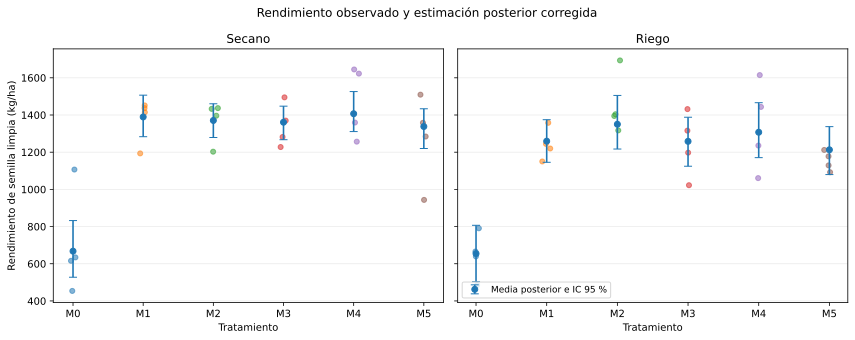

In [2]:
show_svg("01_yield_observed_posterior.svg")

*Figura 1. Observaciones de las cuatro parcelas por tratamiento y medias posteriores del modelo A corregido. Las barras representan intervalos creíbles de 95%.*

### 3.2 Calendario superior versus equivalencia práctica

El modelo principal no identificó un ganador inequívoco. En secano, M4 tuvo la mayor probabilidad de ser el mejor calendario, pero esa probabilidad fue solo **43,0%**. En riego, M2 alcanzó **57,7%**. En ambos casos existe una cantidad considerable de masa posterior asignada a otros calendarios.

Con el margen provisional de 100 kg/ha, la mediana del rango M1–M5 fue de **96,3 kg/ha** en secano y **174,1 kg/ha** en riego. La probabilidad de superar el margen fue 48,3% y 75,9%, respectivamente. Sin embargo, esas probabilidades cambian al modificar cuánto se agrupan los cinco efectos:

| Especificación        | P(rango >100), secano   | P(rango >100), riego   |
|:----------------------|:------------------------|:-----------------------|
| Regularización fuerte | 40,0%                   | 62,1%                  |
| Principal             | 48,3%                   | 75,9%                  |
| Regularización débil  | 53,1%                   | 79,2%                  |
| Casi no agrupado      | 97,0%                   | 99,6%                  |

<div class="warn"><strong>Resultado robusto:</strong> no se demostró equivalencia práctica. <strong>Resultado no robusto:</strong> una cifra única y precisa para la probabilidad de superar 100 kg/ha. El máximo–mínimo es especialmente sensible cuando se estiman cinco medias con cuatro bloques cada una.</div>

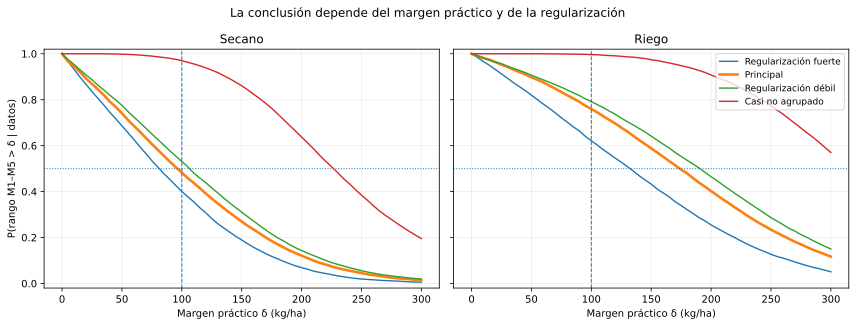

In [3]:
show_svg("02_margin_prior_sensitivity.svg")

*Figura 2. Probabilidad posterior de que el rango entre M1–M5 supere cada margen práctico. La línea vertical marca 100 kg/ha; la especificación principal se muestra con mayor grosor.*

La pregunta de decisión también puede formularse como la probabilidad de que cada calendario quede suficientemente cerca del mejor, en lugar de exigir que sea exactamente el primero. Esta presentación evita exagerar diferencias pequeñas entre tratamientos con rendimientos prácticamente semejantes.

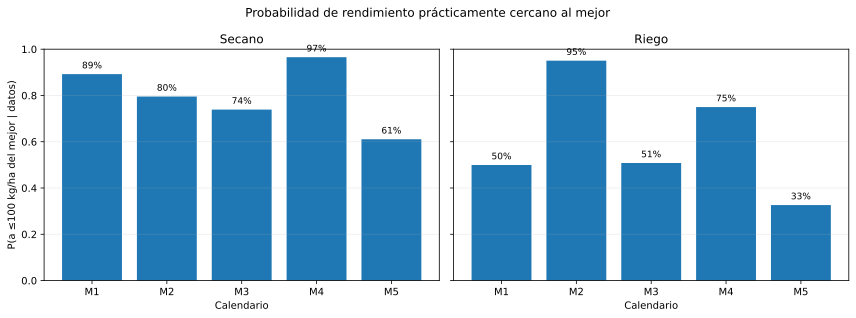

In [4]:
show_svg("03_near_optimal_probabilities.svg")

*Figura 3. Probabilidad de que cada calendario se encuentre a no más de 100 kg/ha del mejor bajo la especificación principal. El margen continúa siendo provisional.*

### 3.3 Contraste temprano–tardío y comparación entre sectores

El contraste promedio M1–M2 menos M4–M5 fue de **3,1 kg/ha** en secano —ICr 95%: -77,9 a 102,7— y de **37,4 kg/ha** en riego —-61,3 a 181,0—. Las probabilidades de una ventaja temprana fueron 56,8% y 76,8%. Por lo tanto, no se obtuvo una ventaja direccional consistente de los calendarios tempranos sobre los tardíos en rendimiento final.

La diferencia entre los dos sectores en ese contraste tuvo una mediana de **32,6 kg/ha**, con ICr 95% de -101,8 a 193,9. La probabilidad de una diferencia sectorial superior a 100 kg/ha en valor absoluto fue 21,5%. Esto favorece una lectura de semejanza en el contraste específico, pero no alcanza para demostrar equivalencia de todo el patrón M1–M5.

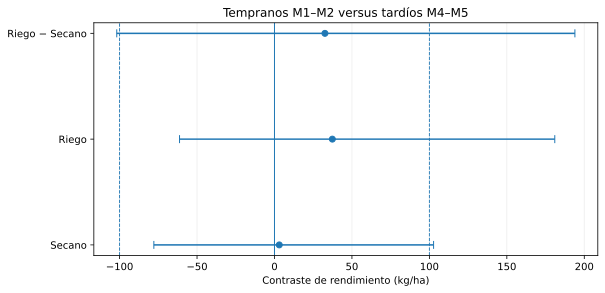

In [5]:
show_svg("04_early_late_sector_contrast.svg")

*Figura 4. Contraste de rendimiento entre calendarios tempranos y tardíos en cada sector, y diferencia de ese contraste entre sectores. Las líneas discontinuas marcan ±100 kg/ha.*

### 3.4 Robustez respecto de los bloques y comportamiento del ANOVA convencional

Al omitir un bloque por vez, $P(R > 100)$ osciló entre **38,6% y 68,9%** en secano, y entre **66,8% y 83,7%** en riego. En cambio, la mediana del efecto adicional de N permaneció entre 657,8 y 766,2 kg/ha en secano, y entre 575,7 y 655,8 kg/ha en riego.

La diferencia es importante: la respuesta a la dosis adicional es estable; la magnitud exacta de las diferencias entre cinco calendarios depende más de pocas unidades experimentales.

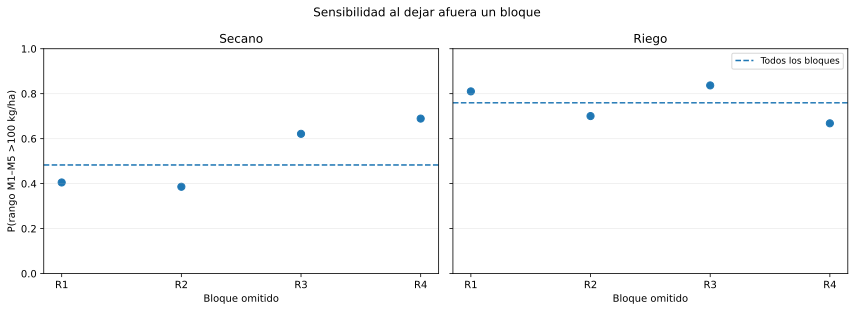

In [6]:
show_svg("05_leave_one_block_out.svg")

*Figura 5. Sensibilidad de la probabilidad de una diferencia mayor de 100 kg/ha al omitir cada bloque. La línea horizontal corresponde al análisis con los cuatro bloques.*

En ensayos completos replicados desde la distribución posterior, el ANOVA M1–M5 volvió a producir $p > 0{,}05$ con alta frecuencia:

| Sector | $P(p_{\mathrm{ANOVA}} > 0{,}05)$ en réplica | $P(p > 0{,}05 \mid R > 100)$ | $P(\text{M5 termina último})$ |
|:---------|:------------------------------|:----------------------------------|:----------------------------------|
| Secano   | 85,0%                         | 75,0%                             | 33,5%                             |
| Riego    | 75,1%                         | 69,1%                             | 39,6%                             |

Aun entre las réplicas cuyo rango latente superaba 100 kg/ha, el análisis convencional permaneció no significativo aproximadamente siete de cada diez veces. Esto no convierte la simulación en una estimación universal de potencia; muestra que, bajo el sistema probabilístico ajustado a estos datos, el resultado "no significativo" es compatible con diferencias prácticas no triviales.

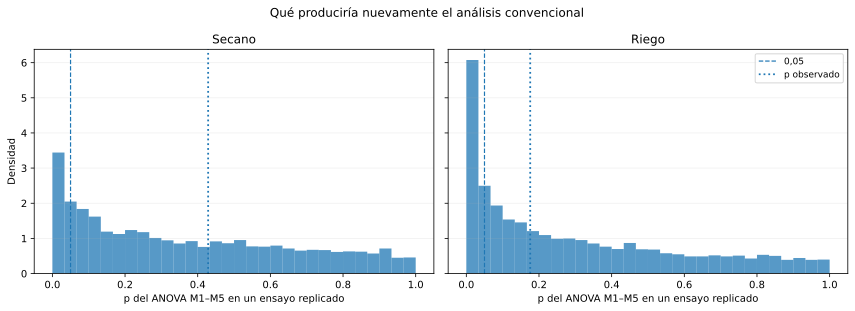

In [7]:
show_svg("06_posterior_predictive_anova.svg")

*Figura 6. Distribución posterior predictiva de los valores p que produciría nuevamente el ANOVA M1–M5. Las líneas verticales indican 0,05 y el valor observado en la tesis.*

### 3.5 Trayectorias de biomasa y concentración de nitrógeno

| Sector   | Variable y fecha    | Contraste     | Mediana [ICr 95%]                | P(dirección)   |
|:---------|:--------------------|:--------------|:---------------------------------|:---------------|
| Secano   | Biomasa, septiembre | M1–M2 − M3–M4 | 2.082 [535; 3.686] kg MS/ha      | 99,7%          |
| Secano   | N, octubre          | M4–M5 − M1–M2 | 0,142 [-0,012; 0,328] puntos % N | 94,9%          |
| Secano   | N, noviembre        | M4–M5 − M1–M2 | 0,053 [-0,044; 0,184] puntos % N | 83,5%          |
| Riego    | Biomasa, septiembre | M1–M2 − M3–M4 | 771 [-80; 1.862] kg MS/ha        | 93,1%          |
| Riego    | N, octubre          | M4–M5 − M1–M2 | 0,318 [0,130; 0,507] puntos % N  | 99,9%          |
| Riego    | N, noviembre        | M4–M5 − M1–M2 | 0,125 [-0,008; 0,262] puntos % N | 96,6%          |

En septiembre, el contraste limpio entre calendarios que ya habían completado la dosis mostró una ventaja temprana de biomasa de **2.082 kg MS/ha** en secano, con probabilidad 99,7%, y de **771 kg MS/ha** en riego, con probabilidad 93,1%. La evidencia fue particularmente clara en secano.

En octubre, la concentración de N se desplazó hacia M4–M5: la diferencia tardíos menos tempranos fue de **0,142 puntos porcentuales** en secano y **0,318** en riego, con probabilidades direccionales de 94,9% y 99,9%. El patrón continuó en noviembre, aunque con intervalos más amplios.

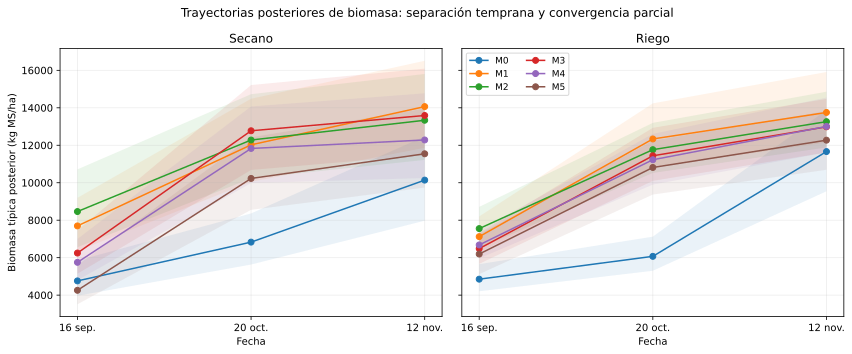

In [8]:
show_svg("07_longitudinal_biomass.svg")

*Figura 7. Trayectorias posteriores de biomasa por tratamiento y sector. Las bandas representan intervalos creíbles de 95%.*

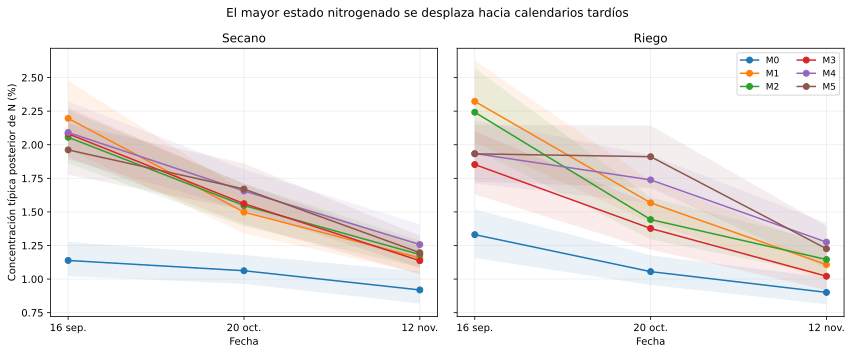

In [9]:
show_svg("08_longitudinal_n_concentration.svg")

*Figura 8. Trayectorias posteriores de concentración de N. El orden de los calendarios se desplaza desde los tratamientos tempranos en septiembre hacia M4–M5 en fechas posteriores.*

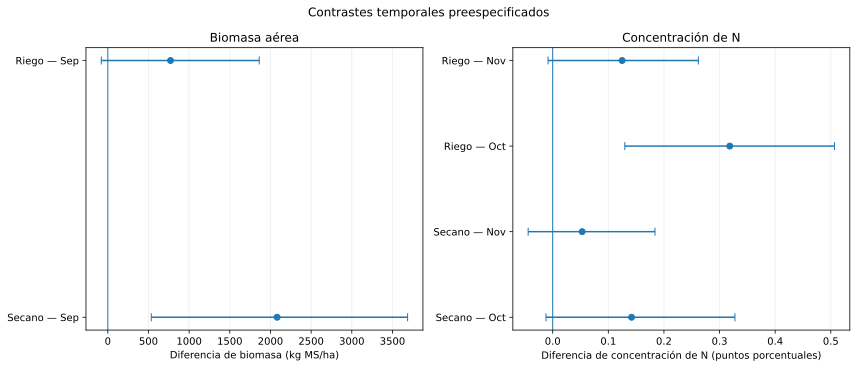

In [10]:
show_svg("09_targeted_longitudinal_contrasts.svg")

*Figura 9. Contrastes temporales preespecificados. Para biomasa de septiembre se excluyó M5 porque aún no había completado la dosis experimental.*

### 3.6 Modelo B: estado nitrogenado latente

| Sector | Mediana del rango final de INN | ICr 95% | $P(\text{rango} > 0{,}10)$ |
|:---------|:---------------------------------|:---------------|:-----------------|
| Secano   | 0,158                            | [0,080; 0,250] | 91,86%           |
| Riego    | 0,239                            | [0,156; 0,334] | 99,95%           |

El modelo B asignó alta probabilidad a que el rango final del INN entre M1–M5 superara 0,10, y M4 presentó la mayor mediana final en ambos sectores. Esto respalda la conclusión de que los calendarios continuaron diferenciándose en su estado nitrogenado relativo aun sin un ganador de rendimiento.

Este resultado se considera **corroborativo y condicionado**, no principal. Depende de errores de observación fijados, de la curva crítica $3{,}93 W^{-0{,}42}$, de su aplicación en etapas reproductivas avanzadas y de los registros de materia seca. No autoriza a interpretar valores menores o mayores que uno como diagnósticos absolutos de deficiencia o suficiencia para Rizar destinado a semilla.

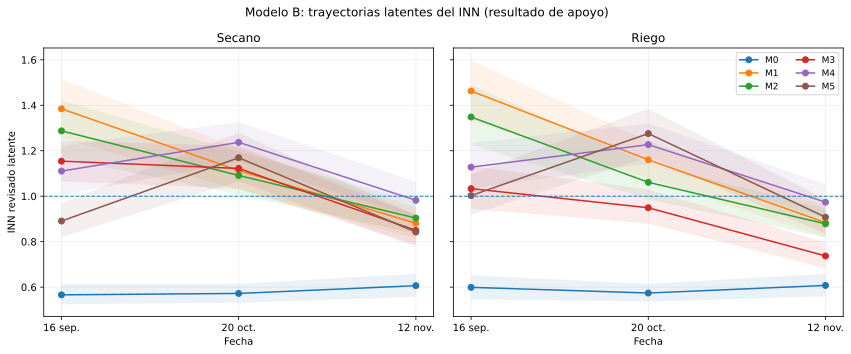

In [11]:
show_svg("10_model_b_nni.svg")

*Figura 10. Trayectorias latentes del INN revisado según el modelo B. La línea horizontal en uno es una referencia, no un umbral absoluto validado para este ensayo.*

### 3.7 Relación inversa entre componentes y nulo de reconstrucción

| Patrón                         | r observado   | Mediana nula   | ICr predictivo 95%   | Percentil observado   |
|:-------------------------------|:--------------|:---------------|:---------------------|:----------------------|
| Parcelas M1–M5, ambos sectores | -0,669        | -0,668         | [-0,821; -0,395]     | 49,7                  |
| Medias M1–M5, Secano           | -0,815        | -0,809         | [-0,984; 0,216]      | 48,9                  |
| Medias M1–M5, Riego            | -0,818        | -0,810         | [-0,988; 0,178]      | 48,5                  |

Las tres correlaciones observadas quedaron prácticamente en la mediana de sus distribuciones nulas: percentiles 49,7, 48,9 y 48,5. Por consiguiente, el patrón inverso no es más extremo que lo que normalmente produce el cálculo de semillas estimadas por panoja a partir de rendimiento, peso de mil semillas y número de panojas.

<div class="key"><strong>Interpretación:</strong> el resultado no demuestra que la compensación biológica haya estado ausente. Demuestra algo más específico: la correlación reconstruida no aporta evidencia independiente a favor de esa compensación. Para identificarla serían necesarios conteos directos de semillas, fertilidad, cuajado, aborto y supervivencia de estructuras.</div>

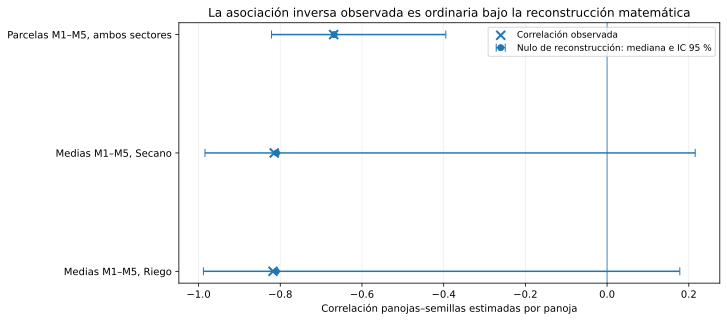

In [12]:
show_svg("11_reconstruction_null.svg")

*Figura 11. Correlaciones observadas frente a la mediana y al intervalo predictivo de 95% del nulo de reconstrucción. Las cruces observadas prácticamente coinciden con las medianas nulas.*

## 4. Discusión en relación con la tesis

| Conclusión de la tesis                                                                     | Aporte probabilístico                                                                                                                   | Relación                                                                               |
|:-------------------------------------------------------------------------------------------|:----------------------------------------------------------------------------------------------------------------------------------------|:---------------------------------------------------------------------------------------|
| Todos los tratamientos con N experimental adicional superaron a M0.                        | La diferencia posterior fue 710,2 kg/ha en secano y 621,7 kg/ha en riego; P(>0) ≈ 100%.                                                 | Confirma y cuantifica la incertidumbre.                                                |
| No se identificó un calendario M1–M5 consistentemente superior.                            | El tratamiento con mayor probabilidad de ser mejor alcanzó solo 43,0% en secano (M4) y 57,7% en riego (M2).                             | Confirma que no existe un ganador claramente identificado.                             |
| La ausencia de significancia no demuestra igualdad exacta.                                 | Con δ=100 kg/ha, P(rango>δ) fue 48,3% y 75,9%, pero cambió mucho con la regularización.                                                 | Refina: no se demostró equivalencia práctica.                                          |
| Las aplicaciones tempranas adelantaron biomasa y las tardías mantuvieron mayor N relativo. | Los contrastes longitudinales asignaron probabilidades altas a ambas direcciones, sobre todo para biomasa en septiembre y N en octubre. | Confirma y expresa la fuerza de la evidencia.                                          |
| La relación inversa entre panojas y semillas estimadas pudo atenuar diferencias.           | El patrón observado quedó aproximadamente en el percentil 49 del nulo generado por la reconstrucción matemática.                        | Restringe: la asociación no aporta evidencia independiente de compensación biológica.  |
| No se obtuvo una interacción momento × sector consistente.                                 | La diferencia sectorial temprano–tardío fue 32,6 kg/ha, con ICr [-101,8; 193,9] y P(|D|>100)=21,5%.                                     | No identifica una diferencia robusta, pero tampoco demuestra equivalencia de patrones. |

### 4.1 Qué queda fortalecido

El reanálisis fortalece dos resultados centrales. Primero, la respuesta al nitrógeno experimental adicional fue grande y estable en ambos sectores. Segundo, la distribución temporal modificó la trayectoria del cultivo: las aplicaciones tempranas adelantaron biomasa, mientras que las tardías mantuvieron mayor concentración relativa de N posteriormente.

### 4.2 Qué debe formularse con mayor precisión

La expresión "no se detectaron diferencias significativas" continúa siendo correcta. No debería transformarse en "los momentos fueron equivalentes". La combinación de intervalos amplios, sensibilidad a la regularización, análisis dejando bloques afuera y simulación posterior predictiva muestra que el diseño no resolvió con precisión suficiente todas las diferencias agronómicamente relevantes.

Tampoco conviene elegir una fecha por su mayor media descriptiva o por su mayor probabilidad de ser exactamente la mejor. M4 en secano y M2 en riego encabezaron sus distribuciones, pero la incertidumbre de clasificación siguió siendo considerable y el orden no fue consistente entre sectores.

### 4.3 Qué interpretación debe restringirse

La relación inversa entre panojas y semillas estimadas por panoja no respalda por sí misma una explicación de compensación. Es compatible con una descomposición contrastante del rendimiento, pero también es exactamente el tipo de patrón que genera la fórmula utilizada. La frase "pudo atenuar las diferencias" debería presentarse como hipótesis agronómica plausible, no como inferencia demostrada por la asociación observada.

### 4.4 Comparación entre sectores

El contraste temprano–tardío no mostró una divergencia sectorial robusta, pero el análisis del patrón completo conservó incertidumbre. Ninguno de esos resultados puede generalizarse como una interacción causal con el riego, porque cada condición hídrica estuvo representada por un solo sector físico.

## 5. Limitaciones del análisis complementario

1. El ensayo incluye un sitio, un ciclo, un cultivar, una dosis experimental y cuatro bloques por tratamiento y sector.
2. M0 representa ausencia de N experimental adicional, no ausencia total de nitrógeno.
3. El margen de 100 kg/ha es provisional. Una conclusión de equivalencia requiere un margen definido agronómica o económicamente antes de examinar los resultados.
4. Las probabilidades sobre el rango M1–M5 son sensibles a la regularización, especialmente porque el máximo y el mínimo seleccionan extremos entre cinco medias inciertas.
5. El modelo longitudinal utiliza niveles típicos en escala logarítmica y no reemplaza la presentación de medias observadas de la tesis.
6. El modelo B fija parte de la incertidumbre de medición y depende de la curva crítica del INN; sus probabilidades son condicionales.
7. Las dos observaciones de materia seca final señaladas en la auditoría deben verificarse antes de convertir Model B en un resultado definitivo.
8. El nulo de reconstrucción evalúa la información contenida en una estadística concreta; no compara exhaustivamente todos los mecanismos biológicos posibles.
9. Los modelos C y D fueron excluidos por mezcla insuficiente y no deben citarse.

## 6. Conclusiones

1. **Respuesta al N adicional.** Bajo las condiciones del ciclo 2025, los 200 kg N/ha experimentales adicionales aumentaron fuertemente el rendimiento respecto de M0. La mediana posterior del aumento fue de 710,2 kg/ha en secano y 621,7 kg/ha en riego.

2. **Rendimiento entre calendarios.** No se identificó un calendario M1–M5 claramente superior. Esta conclusión coincide con el análisis convencional. Sin embargo, el ensayo tampoco demostró equivalencia práctica entre los cinco calendarios.

3. **Trayectoria temporal.** Las aplicaciones tempranas adelantaron la acumulación de biomasa. Las aplicaciones tardías presentaron una alta probabilidad de mantener mayores concentraciones de N en octubre y, con menor precisión, en noviembre. Las diferencias de trayectoria no generaron una ventaja consistente de rendimiento final.

4. **Componentes del rendimiento.** La relación inversa entre densidad de panojas y semillas estimadas por panoja quedó aproximadamente en el centro de la distribución generada por la reconstrucción matemática. No constituye evidencia independiente de compensación biológica.

5. **Sectores.** No se identificó una diferencia robusta entre sectores en el contraste temprano–tardío, pero tampoco se demostró equivalencia del patrón completo. La comparación describe únicamente los dos sectores observados y no estima causalmente una interacción con el riego.

6. **Alcance.** El aporte principal del análisis probabilístico no es seleccionar una fecha, sino separar tres afirmaciones distintas: hubo una respuesta clara al N adicional; el momento modificó la trayectoria del cultivo; y la precisión disponible no permite afirmar ni un calendario ganador ni equivalencia completa.

## 7. Propuesta de redacción para incorporar como anexo

> El análisis probabilístico complementario confirmó una respuesta grande y robusta al nitrógeno experimental adicional respecto de M0. Entre M1–M5 no se identificó un calendario claramente superior; sin embargo, la ausencia de significancia del análisis convencional tampoco demostró equivalencia práctica. La probabilidad de diferencias superiores a un margen agronómico dependió del margen seleccionado y del grado de regularización, lo que reflejó la precisión limitada de cuatro bloques por tratamiento.
>
> Las distribuciones posteriores respaldaron un desplazamiento temporal de la respuesta. Las aplicaciones tempranas adelantaron la producción de biomasa, mientras que las aplicaciones tardías presentaron mayor probabilidad de mantener concentraciones superiores de nitrógeno durante octubre y noviembre. Estas diferencias de trayectoria no se tradujeron en una ventaja consistente de rendimiento final.
>
> La asociación inversa entre la densidad de panojas y el número estimado de semillas por panoja se ubicó aproximadamente en el centro de la distribución producida por un modelo nulo de reconstrucción matemática. Por lo tanto, esa asociación no aportó evidencia independiente de compensación biológica. Los resultados son compatibles con descomposiciones contrastantes del rendimiento, pero para identificar procesos compensatorios sería necesario medir directamente la formación y supervivencia de las estructuras reproductivas.
>
> La comparación probabilística entre sectores no identificó una divergencia robusta del contraste temprano–tardío, aunque conservó incertidumbre sobre el patrón completo. Esta comparación se restringe a los dos sectores físicos evaluados y no constituye una estimación causal generalizable del efecto del riego.

## 8. Reproducibilidad y archivos

El cuaderno utiliza resultados guardados en `results/tables`, figuras en `results/figures` y las cadenas corregidas del modelo A de rendimiento en `results/posteriors`. El código de cálculo se conserva en `code/festuca_annex_v2_analysis.py`; no se muestra en el cuerpo porque el documento fue diseñado para lectura agronómica.

**Fuentes incluidas:**

- `sources/Datos_Ema_Serrana_INN.xlsx`
- `sources/Tesis_v26_caracterizacion_sitio_completa.docx`

**Proveniencia:** el modelo A de rendimiento fue recalculado en esta versión. Los resultados longitudinales del modelo A, el modelo B y el nulo de reconstrucción se importaron de la corrida probabilística entregada y se conservaron únicamente cuando sus diagnósticos fueron aceptables.